In [2]:
from datasets import load_dataset

print("Loading PlantVillage dataset...")

dataset = load_dataset(
    "geraldmc/plantvillage-full",
    revision="v0.1.0"
)

print("Dataset loaded successfully!")
print(dataset)

Loading PlantVillage dataset...


data/train-00001-of-00002.parquet: reconstructing file:   0%|          |  0.00B /  453MB            

data/train-00001-of-00002.parquet: downloading bytes:           |  0.00B            

Generating train split:   0%|          | 0/54304 [00:00<?, ? examples/s]

Dataset loaded successfully!
DatasetDict({
    train: Dataset({
        features: ['image', 'class_label', 'class_idx', 'host', 'disease', 'split', 'leaf_id', 'leaf_grouped'],
        num_rows: 54304
    })
})


In [3]:
print(dataset)

DatasetDict({
    train: Dataset({
        features: ['image', 'class_label', 'class_idx', 'host', 'disease', 'split', 'leaf_id', 'leaf_grouped'],
        num_rows: 54304
    })
})


In [4]:
print(dataset["train"])

Dataset({
    features: ['image', 'class_label', 'class_idx', 'host', 'disease', 'split', 'leaf_id', 'leaf_grouped'],
    num_rows: 54304
})


In [5]:
print(dataset["train"].features)

{'image': Image(mode=None, decode=True), 'class_label': Value('string'), 'class_idx': Value('int32'), 'host': Value('string'), 'disease': Value('string'), 'split': Value('string'), 'leaf_id': Value('string'), 'leaf_grouped': Value('bool')}


In [6]:


train_data = dataset["train"]

print("Total images:", len(train_data))

Total images: 54304


In [7]:
print(train_data.column_names)

['image', 'class_label', 'class_idx', 'host', 'disease', 'split', 'leaf_id', 'leaf_grouped']


In [8]:
sample = train_data[0]

print(sample.keys())

dict_keys(['image', 'class_label', 'class_idx', 'host', 'disease', 'split', 'leaf_id', 'leaf_grouped'])


In [9]:
print(sample)

{'image': <PIL.JpegImagePlugin.JpegImageFile image mode=RGB size=256x256 at 0x1530B0C3DC0>, 'class_label': 'Apple___Apple_scab', 'class_idx': 0, 'host': 'Apple', 'disease': 'Apple scab', 'split': 'test', 'leaf_id': 'Apple___Apple_scab::leaf_79', 'leaf_grouped': True}


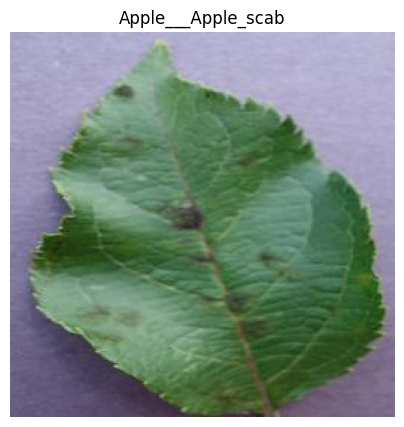

In [10]:
import matplotlib.pyplot as plt

sample = train_data[0]

plt.figure(figsize=(5, 5))
plt.imshow(sample["image"])
plt.axis("off")
plt.title(str(sample["class_label"]))

plt.show()

In [11]:
image = train_data[0]["image"]

print("Image type:", type(image))
print("Image size:", image.size)
print("Image mode:", image.mode)

Image type: <class 'PIL.JpegImagePlugin.JpegImageFile'>
Image size: (256, 256)
Image mode: RGB


In [12]:
features = train_data.features

print(features)

{'image': Image(mode=None, decode=True), 'class_label': Value('string'), 'class_idx': Value('int32'), 'host': Value('string'), 'disease': Value('string'), 'split': Value('string'), 'leaf_id': Value('string'), 'leaf_grouped': Value('bool')}


In [14]:
class_names = features['class_label'].names

print("Number of classes:", len(class_names))

for i, name in enumerate(class_names):
    print(i, ":", name)

AttributeError: 'Value' object has no attribute 'names'

In [15]:
print(train_data.features)

{'image': Image(mode=None, decode=True), 'class_label': Value('string'), 'class_idx': Value('int32'), 'host': Value('string'), 'disease': Value('string'), 'split': Value('string'), 'leaf_id': Value('string'), 'leaf_grouped': Value('bool')}


In [16]:
print(train_data.column_names)

['image', 'class_label', 'class_idx', 'host', 'disease', 'split', 'leaf_id', 'leaf_grouped']


In [17]:
print(train_data[0])

{'image': <PIL.JpegImagePlugin.JpegImageFile image mode=RGB size=256x256 at 0x1530D193AC0>, 'class_label': 'Apple___Apple_scab', 'class_idx': 0, 'host': 'Apple', 'disease': 'Apple scab', 'split': 'test', 'leaf_id': 'Apple___Apple_scab::leaf_79', 'leaf_grouped': True}


In [18]:
for i in range(5):
    print(train_data[i])
    print("-" * 80)

{'image': <PIL.JpegImagePlugin.JpegImageFile image mode=RGB size=256x256 at 0x1530D193B80>, 'class_label': 'Apple___Apple_scab', 'class_idx': 0, 'host': 'Apple', 'disease': 'Apple scab', 'split': 'test', 'leaf_id': 'Apple___Apple_scab::leaf_79', 'leaf_grouped': True}
--------------------------------------------------------------------------------
{'image': <PIL.JpegImagePlugin.JpegImageFile image mode=RGB size=256x256 at 0x1530D191AB0>, 'class_label': 'Apple___Apple_scab', 'class_idx': 0, 'host': 'Apple', 'disease': 'Apple scab', 'split': 'test', 'leaf_id': 'Apple___Apple_scab::leaf_19', 'leaf_grouped': True}
--------------------------------------------------------------------------------
{'image': <PIL.JpegImagePlugin.JpegImageFile image mode=RGB size=256x256 at 0x1530D191630>, 'class_label': 'Apple___Apple_scab', 'class_idx': 0, 'host': 'Apple', 'disease': 'Apple scab', 'split': 'test', 'leaf_id': 'Apple___Apple_scab::leaf_39', 'leaf_grouped': True}
----------------------------------

In [19]:
print(train_data.features)
print(train_data.column_names)
print(train_data[0])

{'image': Image(mode=None, decode=True), 'class_label': Value('string'), 'class_idx': Value('int32'), 'host': Value('string'), 'disease': Value('string'), 'split': Value('string'), 'leaf_id': Value('string'), 'leaf_grouped': Value('bool')}
['image', 'class_label', 'class_idx', 'host', 'disease', 'split', 'leaf_id', 'leaf_grouped']
{'image': <PIL.JpegImagePlugin.JpegImageFile image mode=RGB size=256x256 at 0x1530D191B10>, 'class_label': 'Apple___Apple_scab', 'class_idx': 0, 'host': 'Apple', 'disease': 'Apple scab', 'split': 'test', 'leaf_id': 'Apple___Apple_scab::leaf_79', 'leaf_grouped': True}


In [20]:
class_names = sorted(train_data.unique("class_label"))

print("Number of classes:", len(class_names))

for i, name in enumerate(class_names):
    print(i, ":", name)

Number of classes: 38
0 : Apple___Apple_scab
1 : Apple___Black_rot
2 : Apple___Cedar_apple_rust
3 : Apple___healthy
4 : Blueberry___healthy
5 : Cherry_(including_sour)___Powdery_mildew
6 : Cherry_(including_sour)___healthy
7 : Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot
8 : Corn_(maize)___Common_rust_
9 : Corn_(maize)___Northern_Leaf_Blight
10 : Corn_(maize)___healthy
11 : Grape___Black_rot
12 : Grape___Esca_(Black_Measles)
13 : Grape___Leaf_blight_(Isariopsis_Leaf_Spot)
14 : Grape___healthy
15 : Orange___Haunglongbing_(Citrus_greening)
16 : Peach___Bacterial_spot
17 : Peach___healthy
18 : Pepper,_bell___Bacterial_spot
19 : Pepper,_bell___healthy
20 : Potato___Early_blight
21 : Potato___Late_blight
22 : Potato___healthy
23 : Raspberry___healthy
24 : Soybean___healthy
25 : Squash___Powdery_mildew
26 : Strawberry___Leaf_scorch
27 : Strawberry___healthy
28 : Tomato___Bacterial_spot
29 : Tomato___Early_blight
30 : Tomato___Late_blight
31 : Tomato___Leaf_Mold
32 : Tomato___Septoria_l

In [21]:
class_mapping = (
    train_data
    .select_columns(["class_idx", "class_label"])
    .to_pandas()
    .drop_duplicates()
    .sort_values("class_idx")
)

print(class_mapping.to_string(index=False))

 class_idx                                        class_label
         0                                 Apple___Apple_scab
         1                                  Apple___Black_rot
         2                           Apple___Cedar_apple_rust
         3                                    Apple___healthy
         4                                Blueberry___healthy
         5           Cherry_(including_sour)___Powdery_mildew
         6                  Cherry_(including_sour)___healthy
         7 Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot
         8                        Corn_(maize)___Common_rust_
         9                Corn_(maize)___Northern_Leaf_Blight
        10                             Corn_(maize)___healthy
        11                                  Grape___Black_rot
        12                       Grape___Esca_(Black_Measles)
        13         Grape___Leaf_blight_(Isariopsis_Leaf_Spot)
        14                                    Grape___healthy
        

In [22]:
print("=" * 60)
print("PLANTVILLAGE DATASET SUMMARY")
print("=" * 60)

print("Total images:", len(train_data))
print("Number of classes:", train_data["class_label"].__len__())
print("Columns:", train_data.column_names)

PLANTVILLAGE DATASET SUMMARY
Total images: 54304
Number of classes: 54304
Columns: ['image', 'class_label', 'class_idx', 'host', 'disease', 'split', 'leaf_id', 'leaf_grouped']


In [23]:
num_classes = len(train_data.unique("class_label"))

print("Number of classes:", num_classes)

Number of classes: 38


In [24]:
hosts = train_data.unique("host")

print("Number of plant species:", len(hosts))

for host in sorted(hosts):
    print(host)

Number of plant species: 14
Apple
Blueberry
Cherry (including sour)
Corn (maize)
Grape
Orange
Peach
Pepper, bell
Potato
Raspberry
Soybean
Squash
Strawberry
Tomato


In [25]:
diseases = train_data.unique("disease")

print("Number of disease labels:", len(diseases))

for disease in sorted(diseases):
    print(disease)

Number of disease labels: 21
Apple scab
Bacterial spot
Black rot
Cedar apple rust
Cercospora leaf spot Gray leaf spot
Common rust
Early blight
Esca (Black Measles)
Haunglongbing (Citrus greening)
Late blight
Leaf Mold
Leaf blight (Isariopsis Leaf Spot)
Leaf scorch
Northern Leaf Blight
Powdery mildew
Septoria leaf spot
Spider mites Two-spotted spider mite
Target Spot
Tomato Yellow Leaf Curl Virus
Tomato mosaic virus
healthy


In [26]:
from collections import Counter

class_counts = Counter(train_data["class_label"])

for class_name, count in sorted(class_counts.items()):
    print(f"{class_name:<45} {count}")

Apple___Apple_scab                            630
Apple___Black_rot                             621
Apple___Cedar_apple_rust                      275
Apple___healthy                               1645
Blueberry___healthy                           1502
Cherry_(including_sour)___Powdery_mildew      1052
Cherry_(including_sour)___healthy             854
Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot 513
Corn_(maize)___Common_rust_                   1192
Corn_(maize)___Northern_Leaf_Blight           985
Corn_(maize)___healthy                        1162
Grape___Black_rot                             1180
Grape___Esca_(Black_Measles)                  1383
Grape___Leaf_blight_(Isariopsis_Leaf_Spot)    1076
Grape___healthy                               423
Orange___Haunglongbing_(Citrus_greening)      5507
Peach___Bacterial_spot                        2297
Peach___healthy                               360
Pepper,_bell___Bacterial_spot                 997
Pepper,_bell___healthy             

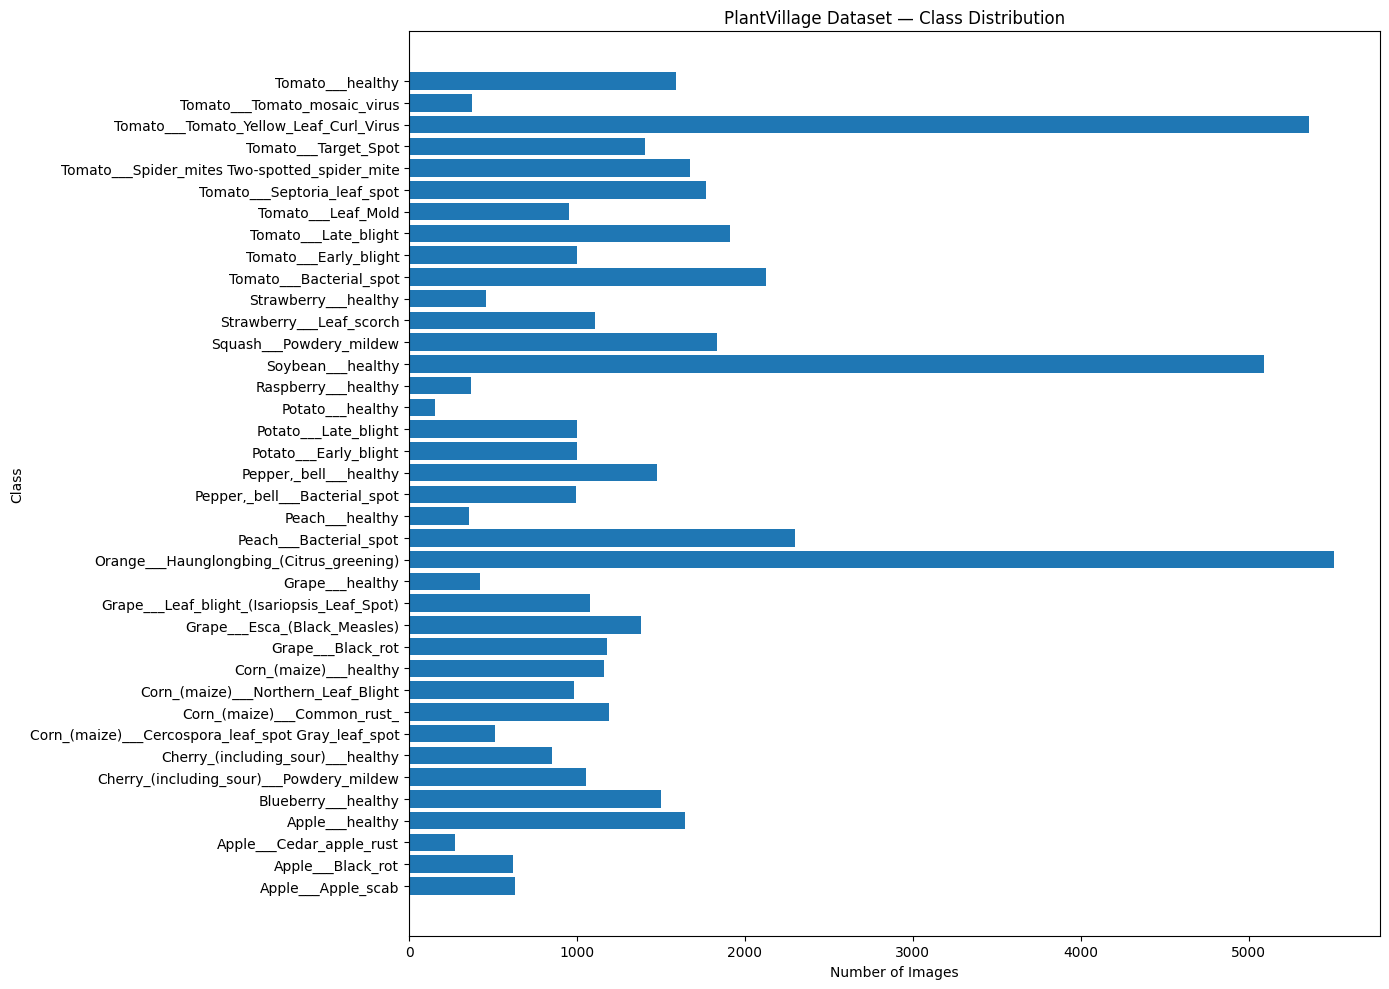

In [27]:
import matplotlib.pyplot as plt

sorted_classes = sorted(class_counts.items())

labels = [item[0] for item in sorted_classes]
counts = [item[1] for item in sorted_classes]

plt.figure(figsize=(14, 10))

plt.barh(labels, counts)

plt.xlabel("Number of Images")
plt.ylabel("Class")
plt.title("PlantVillage Dataset — Class Distribution")

plt.tight_layout()
plt.show()

In [28]:
split_counts = Counter(train_data["split"])

print(split_counts)

Counter({'train': 43356, 'test': 10948})


In [29]:
for split, count in split_counts.items():
    percentage = count / len(train_data) * 100
    print(f"{split}: {count:,} ({percentage:.2f}%)")

test: 10,948 (20.16%)
train: 43,356 (79.84%)


In [30]:
import pandas as pd

df = train_data.to_pandas()

split_distribution = pd.crosstab(
    df["class_label"],
    df["split"]
)

print(split_distribution)

split                                               test  train
class_label                                                    
Apple___Apple_scab                                   123    507
Apple___Black_rot                                    124    497
Apple___Cedar_apple_rust                              55    220
Apple___healthy                                      324   1321
Blueberry___healthy                                  278   1224
Cherry_(including_sour)___Powdery_mildew             252    800
Cherry_(including_sour)___healthy                    179    675
Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot   103    410
Corn_(maize)___Common_rust_                          238    954
Corn_(maize)___Northern_Leaf_Blight                  197    788
Corn_(maize)___healthy                               232    930
Grape___Black_rot                                    236    944
Grape___Esca_(Black_Measles)                         275   1108
Grape___Leaf_blight_(Isariopsis_Leaf_Spo

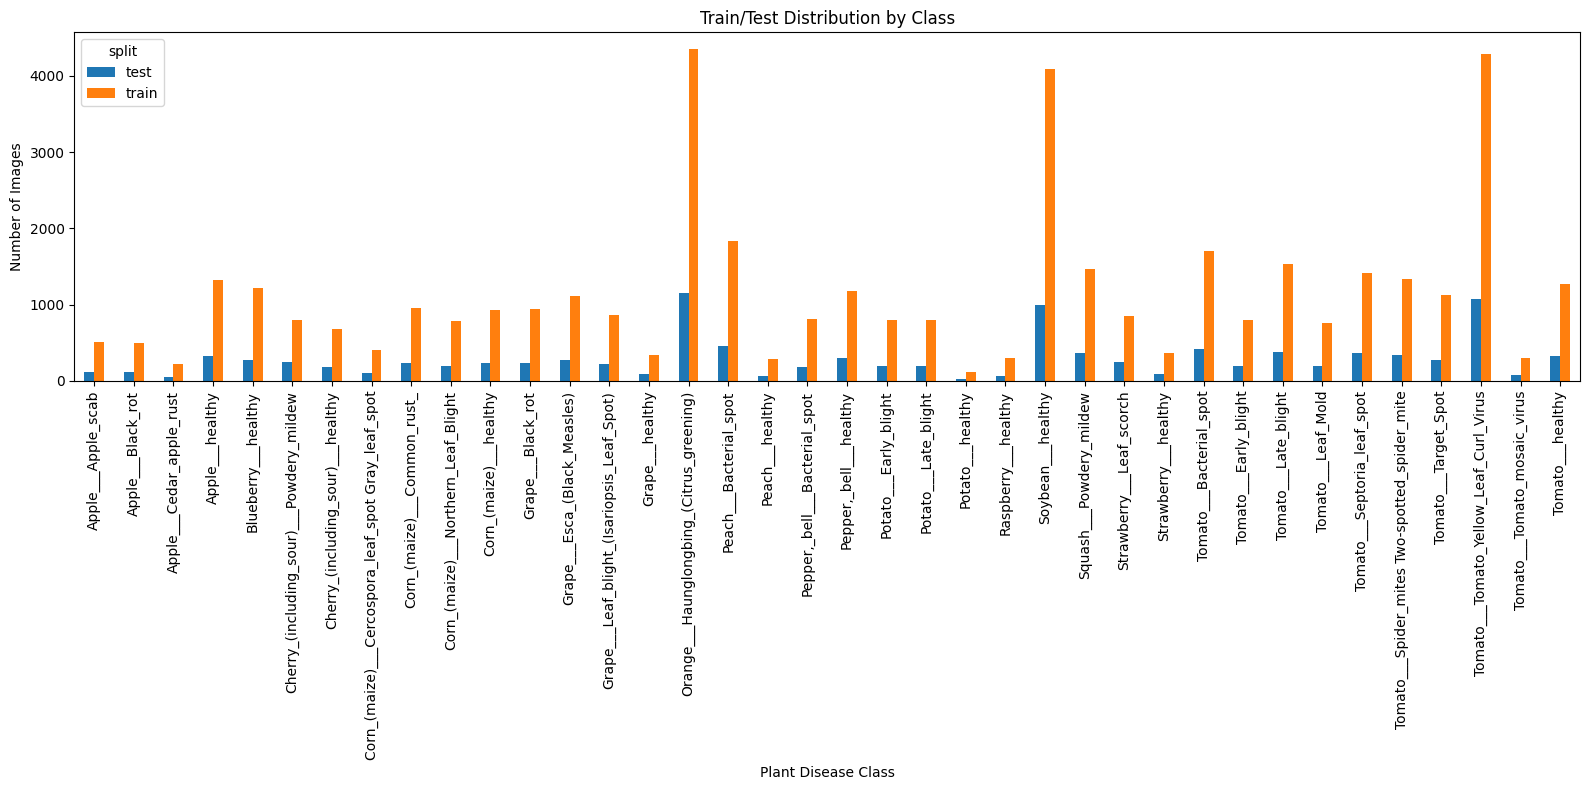

In [31]:
split_distribution.plot(
    kind="bar",
    figsize=(16, 8)
)

plt.title("Train/Test Distribution by Class")
plt.xlabel("Plant Disease Class")
plt.ylabel("Number of Images")

plt.xticks(rotation=90)

plt.tight_layout()
plt.show()

In [32]:
healthy_classes = [
    cls for cls in class_names
    if "healthy" in cls.lower()
]

print("Healthy classes:")
for cls in healthy_classes:
    print(cls)

Healthy classes:
Apple___healthy
Blueberry___healthy
Cherry_(including_sour)___healthy
Corn_(maize)___healthy
Grape___healthy
Peach___healthy
Pepper,_bell___healthy
Potato___healthy
Raspberry___healthy
Soybean___healthy
Strawberry___healthy
Tomato___healthy


In [33]:
healthy_count = sum(
    class_counts[cls]
    for cls in healthy_classes
)

diseased_count = len(train_data) - healthy_count

print("Healthy images:", healthy_count)
print("Diseased images:", diseased_count)

Healthy images: 15083
Diseased images: 39221


In [34]:
print("Leaf grouping values:")
print(Counter(train_data["leaf_grouped"]))

Leaf grouping values:
Counter({True: 36526, False: 17778})


In [35]:
unique_leaves = len(set(train_data["leaf_id"]))

print("Total images:", len(train_data))
print("Unique leaf IDs:", unique_leaves)

Total images: 54304
Unique leaf IDs: 24385


In [36]:
leaf_split = (
    df.groupby("leaf_id")["split"]
    .nunique()
)

print("Leaf IDs appearing in multiple splits:",
      (leaf_split > 1).sum())

Leaf IDs appearing in multiple splits: 0
